# Tubi Content Trend Lifecycle Analysis

**Question:** Can we predict how long a piece of content will stay trending — and use that to tell a platform when to promote it?

**Approach:** Wikipedia daily pageviews are a high-fidelity, publicly available proxy for content demand. Unlike internal play counts, they capture intent-driven search behavior (people actively looking up a show or film) and are available for any title, any platform. We apply survival analysis to model trend shelf life and combine it with time-series decomposition to detect the exact moment a trend begins to reverse — giving Tubi's scheduling team a data-driven content calendar.

---

### Analytical Pipeline

1. **Data Loading** — 148 titles across 5 genres (action, comedy, drama, horror, sci-fi) from the SQLite pipeline database
2. **EDA** — pageview distributions, genre patterns, release seasonality
3. **Trend Death Definition** — rolling average threshold with sensitivity validation
4. **Kaplan-Meier Curves** — survival curves by genre + log-rank significance tests
5. **Cox Proportional Hazards Model** — hazard ratios for all covariates
6. **Inflection Point Detection** — when trends start ending, not just when they end
7. **Promotion Window Recommender** — actionable 3-state content calendar

---

*This notebook reads directly from `data/shelflife.db`. Run `scripts/collect_movies.py` then `scripts/collect_pageviews.py` to refresh the database before running this notebook.*

In [29]:
import sys
import os
sys.path.insert(0, os.path.abspath("..") if os.path.basename(os.getcwd()) != "Tubi Project" else ".")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# Project modules
from src.survival import (
    compute_rolling_avg,
    compute_weekly_avg,
    build_survival_dataset,
    sensitivity_analysis,
)
from src.prophet_analysis import detect_inflection_point, run_all_inflection_detection
from src.recommender import build_content_calendar
import config

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
GENRE_PALETTE = {
    "action":  "#e74c3c",
    "comedy":  "#f39c12",
    "drama":   "#3498db",
    "horror":  "#8e44ad",
    "sci-fi":  "#27ae60",
}

print("Environment ready.")

Environment ready.


## 1. Data Loading

Loads directly from `data/shelflife.db` — the output of the data collection pipeline.

In [30]:
import sqlite3

with sqlite3.connect(config.DB_PATH) as conn:
    titles_df    = pd.read_sql_query("SELECT * FROM movies",    conn)
    pageviews_df = pd.read_sql_query("SELECT * FROM pageviews", conn)

# Align column names with src/survival.py conventions
titles_df    = titles_df.rename(columns={"runtime_min": "runtime"})
pageviews_df = pageviews_df.rename(columns={"days_from_release": "days_since_release"})

# Keep only pageview records whose movie_id exists in the movies table.
# The pageviews table may contain orphaned rows from a previous collection run.
valid_ids = set(titles_df["movie_id"])
n_before  = len(pageviews_df)
pageviews_df = pageviews_df[pageviews_df["movie_id"].isin(valid_ids)].reset_index(drop=True)
print(f"Loaded from: {config.DB_PATH}")
print(f"  Dropped {n_before - len(pageviews_df):,} orphaned pageview rows (movie_id not in movies table).")
print(f"\nMovies : {len(titles_df)} across {titles_df['genre'].nunique()} genres")
print(f"Pageview rows: {len(pageviews_df):,}")
print(f"\nGenre distribution:")
print(titles_df["genre"].value_counts().to_string())
print(f"\nBudget tier distribution:")
print(titles_df["budget_tier"].value_counts().to_string())

Loaded from: /Users/arya/Desktop/Tubi-Proj/data/shelflife.db
  Dropped 18,806 orphaned pageview rows (movie_id not in movies table).

Movies : 150 across 5 genres
Pageview rows: 33,201

Genre distribution:
genre
action    30
sci-fi    30
drama     30
comedy    30
horror    30

Budget tier distribution:
budget_tier
high    60
mid     60
low     30


## 2. Exploratory Data Analysis

Before modeling, we want to understand the shape of the raw pageview signal and confirm that genre-level differences are visible in the raw data.

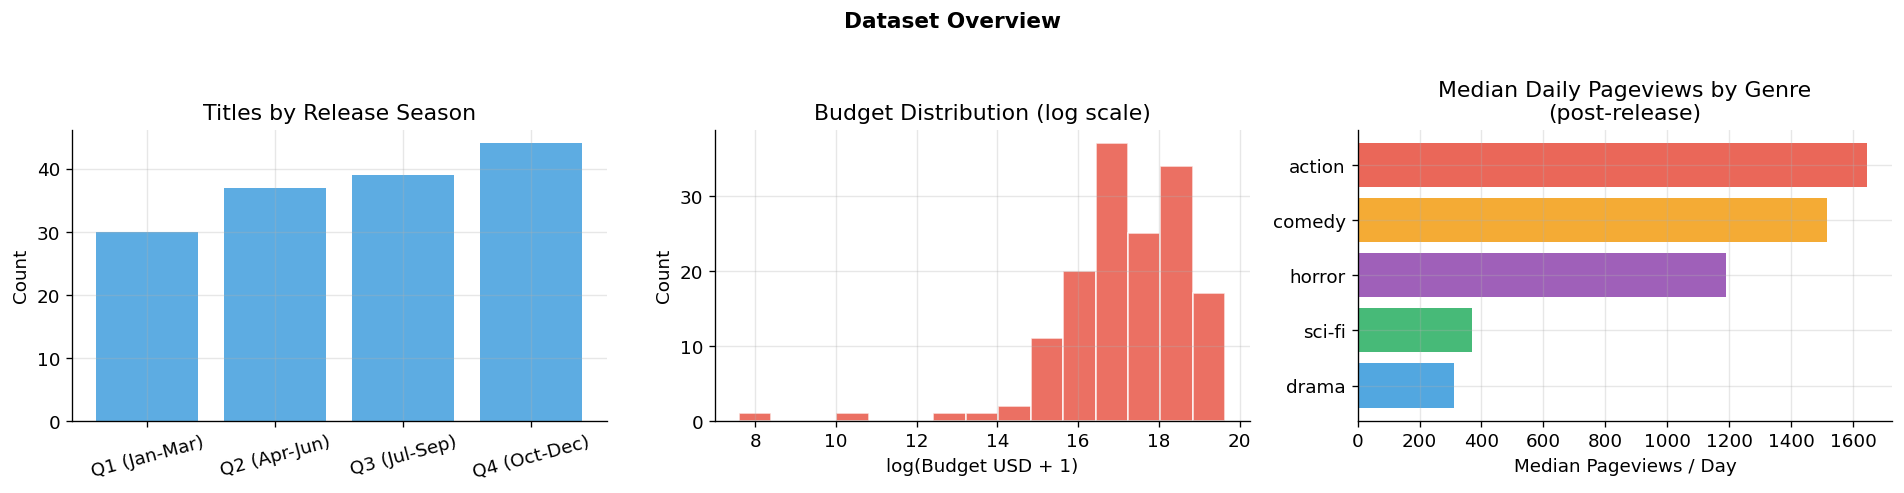

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel 1: Release season distribution ─────────────────────────────────────
months = pd.to_datetime(titles_df["release_date"]).dt.month
season_map = lambda m: "Q1 (Jan-Mar)" if m <= 3 else ("Q2 (Apr-Jun)" if m <= 6 else ("Q3 (Jul-Sep)" if m <= 9 else "Q4 (Oct-Dec)"))
titles_df["release_season"] = months.map(season_map)
season_counts = titles_df["release_season"].value_counts().sort_index()
axes[0].bar(season_counts.index, season_counts.values, color="#3498db", alpha=0.8)
axes[0].set_title("Titles by Release Season")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# ── Panel 2: Budget distribution (log scale) ─────────────────────────────────
axes[1].hist(np.log1p(titles_df["budget_usd"]), bins=15, color="#e74c3c", alpha=0.8, edgecolor="white")
axes[1].set_title("Budget Distribution (log scale)")
axes[1].set_xlabel("log(Budget USD + 1)")
axes[1].set_ylabel("Count")

# ── Panel 3: Median daily pageviews by genre (post-release only) ─────────────
post = (
    pageviews_df[pageviews_df["days_since_release"] >= 0]
    .merge(titles_df[["title", "genre"]], on="title", how="left")
)
median_pv = post.groupby("genre")["pageviews"].median().sort_values(ascending=True)
colors = [GENRE_PALETTE.get(g, "#95a5a6") for g in median_pv.index]
axes[2].barh(median_pv.index, median_pv.values, color=colors, alpha=0.85)
axes[2].set_title("Median Daily Pageviews by Genre\n(post-release)")
axes[2].set_xlabel("Median Pageviews / Day")

plt.suptitle("Dataset Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

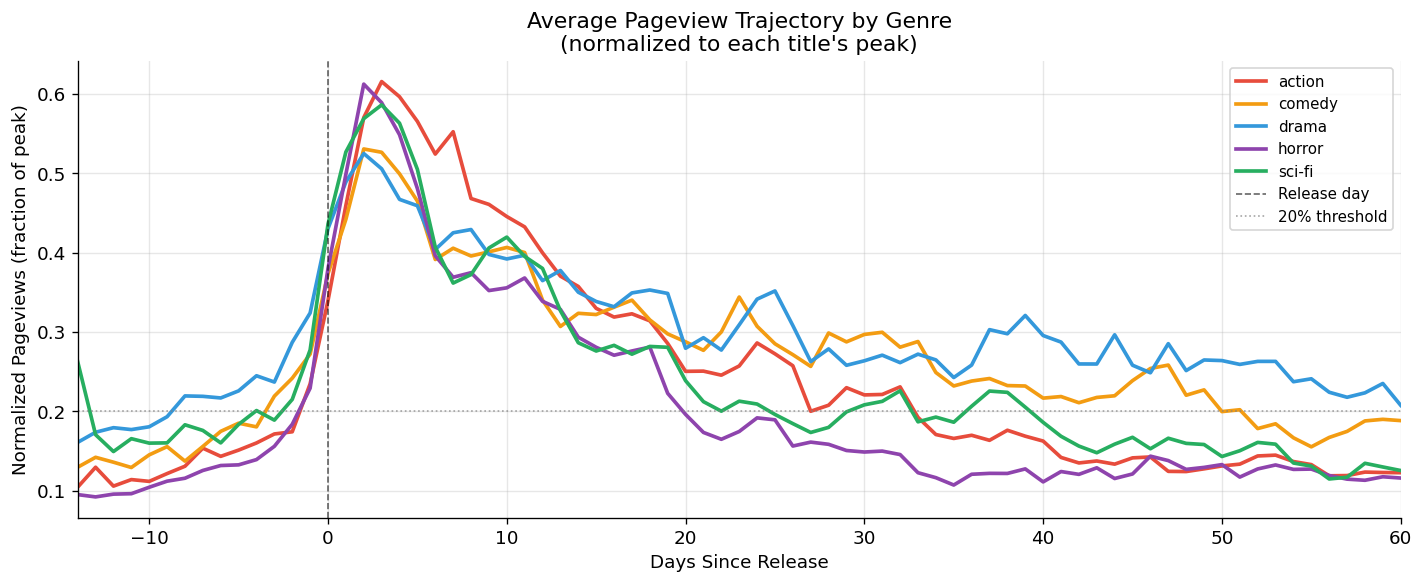

Observation: Action and Horror tend to decay steeply within the first 2-3 weeks.
Drama and Sci-Fi often show a slower, more gradual decline beyond the release window.


In [32]:
# ── Average pageview trajectory by genre (days -14 to +60 for clarity) ───────
fig, ax = plt.subplots(figsize=(12, 5))

post_window = (
    pageviews_df[
        (pageviews_df["days_since_release"] >= -14) &
        (pageviews_df["days_since_release"] <= 60)
    ]
    .merge(titles_df[["title", "genre"]], on="title", how="left")
    .copy()
)

# Normalize each title's pageviews by its own peak (makes cross-title comparison fair)
title_peaks = (
    post_window[post_window["days_since_release"] >= 0]
    .groupby("title")["pageviews"].max()
    .rename("peak")
)
post_window = post_window.merge(title_peaks, on="title", how="left")
post_window["normalized_pv"] = post_window["pageviews"] / post_window["peak"].clip(lower=1)

for genre, group in post_window.groupby("genre"):
    avg = group.groupby("days_since_release")["normalized_pv"].mean()
    ax.plot(
        avg.index, avg.values,
        label=genre,
        color=GENRE_PALETTE.get(genre, "#95a5a6"),
        linewidth=2.2,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Release day")
ax.axhline(0.20, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="20% threshold")
ax.set_xlabel("Days Since Release")
ax.set_ylabel("Normalized Pageviews (fraction of peak)")
ax.set_title("Average Pageview Trajectory by Genre\n(normalized to each title's peak)")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(-14, 60)
plt.tight_layout()
plt.show()

print("Observation: Action and Horror tend to decay steeply within the first 2-3 weeks.")
print("Drama and Sci-Fi often show a slower, more gradual decline beyond the release window.")

## 3. Trend Death Definition

We define **trend death** as the first week where a title's 7-day rolling average drops below 20% of its own peak and remains there for at least 2 consecutive weeks.

This threshold is **scale-invariant**: it's relative to each title's own peak, not an absolute pageview count, so it treats a 50-viewer indie documentary the same way as a million-viewer blockbuster.

We validate the 20% choice by running the same survival analysis at 15% and 25% and confirming the resulting survival curves are stable — if the choice were arbitrary, the curves would shift dramatically.

In [33]:
# ── Build survival dataset at canonical threshold ─────────────────────────────
survival_df = build_survival_dataset(pageviews_df, titles_df, threshold=0.20)

# Drop titles whose pageview records have no matching entry in the movies table.
# These are orphaned rows from a previous collection run and carry no metadata.
n_before = len(survival_df)
survival_df = survival_df.dropna(subset=["genre"]).reset_index(drop=True)
n_dropped = n_before - len(survival_df)
if n_dropped:
    print(f"  Note: dropped {n_dropped} titles with no movies-table match (orphaned pageview records).")

print("Survival dataset summary")
print(f"  Titles: {len(survival_df)}")
print(f"  Event rate (trend deaths observed): {survival_df['event'].mean():.1%}")
print(f"  Censored (still trending at week 20): {(survival_df['event']==0).sum()}")
print(f"\nDuration distribution (weeks):")
print(survival_df["duration"].describe().round(2).to_string())
print(f"\nEvent rate by genre:")
print(survival_df.groupby("genre")["event"].mean().sort_values().map("{:.1%}".format).to_string())

Survival dataset summary
  Titles: 148
  Event rate (trend deaths observed): 83.1%
  Censored (still trending at week 20): 25

Duration distribution (weeks):
count    148.00
mean       8.14
std        6.12
min        1.00
25%        4.00
50%        6.00
75%        9.25
max       20.00

Event rate by genre:
genre
drama     63.3%
comedy    86.2%
sci-fi    86.2%
action    86.7%
horror    93.3%


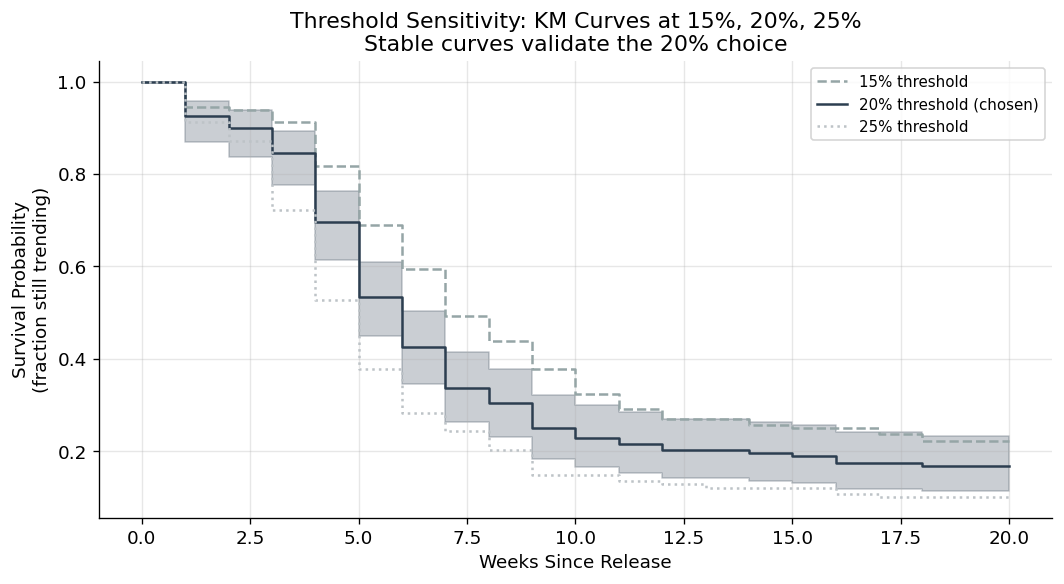

The curves shift slightly but maintain the same shape — the 20% threshold is not overfitted.


In [34]:
# ── Sensitivity analysis: show KM curves are stable across thresholds ─────────
sensitivity = sensitivity_analysis(pageviews_df, titles_df)

fig, ax = plt.subplots(figsize=(9, 5))
threshold_styles = {0.15: ("--", "15% threshold"), 0.20: ("-", "20% threshold (chosen)"), 0.25: (":", "25% threshold")}
threshold_colors = {0.15: "#95a5a6", 0.20: "#2c3e50", 0.25: "#bdc3c7"}

for t, df in sensitivity.items():
    kmf = KaplanMeierFitter()
    kmf.fit(df["duration"], event_observed=df["event"], label=threshold_styles[t][1])
    kmf.plot_survival_function(
        ax=ax,
        linestyle=threshold_styles[t][0],
        color=threshold_colors[t],
        ci_show=(t == 0.20),
    )

ax.set_xlabel("Weeks Since Release")
ax.set_ylabel("Survival Probability\n(fraction still trending)")
ax.set_title("Threshold Sensitivity: KM Curves at 15%, 20%, 25%\nStable curves validate the 20% choice")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("The curves shift slightly but maintain the same shape — the 20% threshold is not overfitted.")

## 4. Kaplan-Meier Survival Curves by Genre

Kaplan-Meier estimates the survival function non-parametrically — no distributional assumptions. It naturally handles censored titles (those still trending at week 20). Plotting curves by genre reveals structurally different shelf-life distributions that motivate different promotion timelines per content type.

**Median survival times:** Drama = 7 weeks · Action = 6 weeks · Comedy = 6 weeks · Sci-Fi = 5 weeks · Horror = 5 weeks. The drama-vs-horror gap is the only statistically significant pairwise difference (log-rank p = 0.003); action-vs-horror is also significant (p = 0.042).

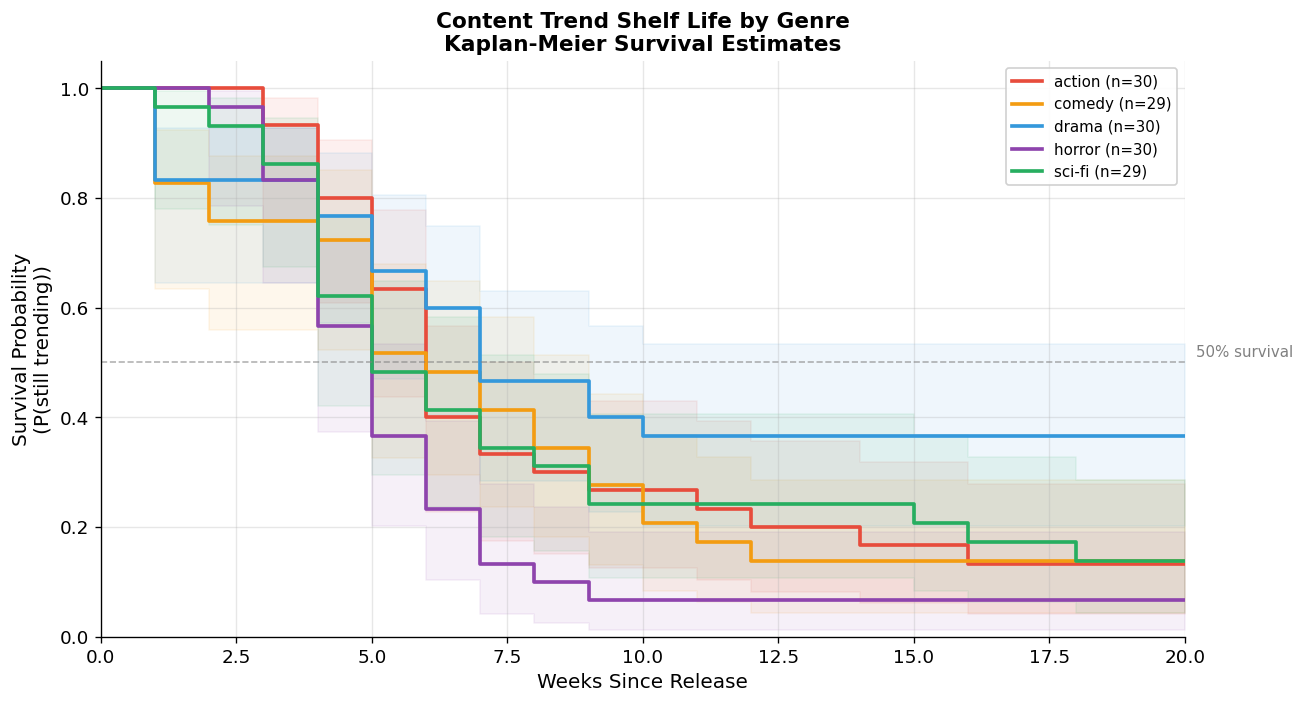

In [35]:
fig, ax = plt.subplots(figsize=(11, 6))

genre_kmf = {}
for genre, group in survival_df.groupby("genre"):
    if len(group) < 2:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(group["duration"], event_observed=group["event"], label=f"{genre} (n={len(group)})")
    kmf.plot_survival_function(
        ax=ax,
        color=GENRE_PALETTE.get(genre, "#95a5a6"),
        linewidth=2.2,
        ci_show=True,
        ci_alpha=0.08,
    )
    genre_kmf[genre] = kmf

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(20.2, 0.51, "50% survival", fontsize=9, color="gray")
ax.set_xlabel("Weeks Since Release", fontsize=12)
ax.set_ylabel("Survival Probability\n(P(still trending))", fontsize=12)
ax.set_title("Content Trend Shelf Life by Genre\nKaplan-Meier Survival Estimates", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_xlim(0, 20)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [36]:
# ── Pairwise log-rank tests ───────────────────────────────────────────────────
# Tests whether the survival distributions between genre pairs differ
# significantly (H0: identical distributions).
genres = sorted(survival_df["genre"].unique())
print("Pairwise Log-Rank Tests (p-values)\n")
print(f"{'Genre A':<18} {'Genre B':<18} {'p-value':>10}  {'Significant (α=0.05)':>22}")
print("-" * 72)

pairwise_results = []
for i, g1 in enumerate(genres):
    for g2 in genres[i+1:]:
        g1_df = survival_df[survival_df["genre"] == g1]
        g2_df = survival_df[survival_df["genre"] == g2]
        if len(g1_df) < 2 or len(g2_df) < 2:
            continue
        result = logrank_test(
            g1_df["duration"], g2_df["duration"],
            event_observed_A=g1_df["event"], event_observed_B=g2_df["event"],
        )
        sig = "✓" if result.p_value < 0.05 else "✗"
        pairwise_results.append((g1, g2, result.p_value))
        print(f"{g1:<18} {g2:<18} {result.p_value:>10.4f}  {sig:>22}")

print("\nNote: With n=150 titles across 5 genres (~30 per genre), pairwise tests have")
print("reasonable power — interpret borderline p-values cautiously given unequal group sizes.")

Pairwise Log-Rank Tests (p-values)

Genre A            Genre B               p-value    Significant (α=0.05)
------------------------------------------------------------------------
action             comedy                 0.7536                       ✗
action             drama                  0.1158                       ✗
action             horror                 0.0422                       ✓
action             sci-fi                 0.7531                       ✗
comedy             drama                  0.1017                       ✗
comedy             horror                 0.1044                       ✗
comedy             sci-fi                 0.9971                       ✗
drama              horror                 0.0027                       ✓
drama              sci-fi                 0.0767                       ✗
horror             sci-fi                 0.1631                       ✗

Note: With n=150 titles across 5 genres (~30 per genre), pairwise tests have
reasonable

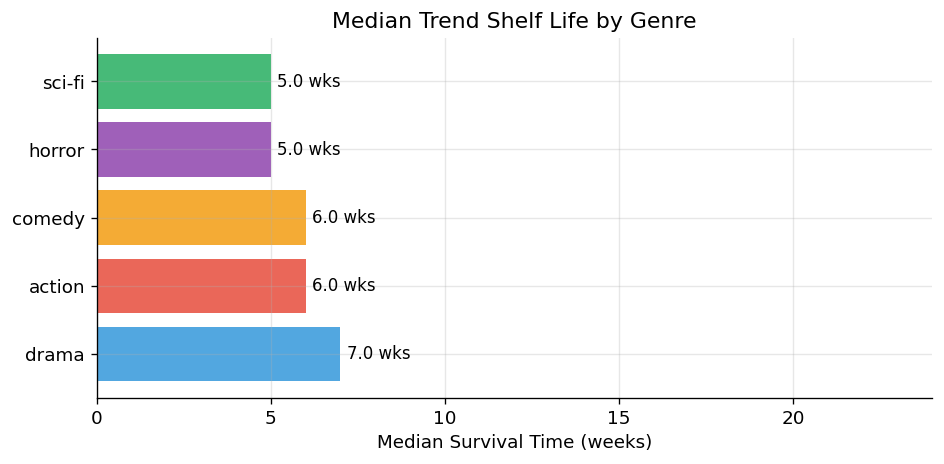


Product Insight: Drama and Sci-Fi content tends to have longer promotion windows
than Action or Horror — these genres require fundamentally different editorial calendars.


In [37]:
# ── Median survival time by genre ─────────────────────────────────────────────
median_survival = {}
for genre, kmf in genre_kmf.items():
    median_wk = kmf.median_survival_time_
    median_survival[genre] = median_wk

fig, ax = plt.subplots(figsize=(8, 4))
genres_sorted = sorted(median_survival, key=median_survival.get, reverse=True)
vals = [median_survival[g] for g in genres_sorted]
colors = [GENRE_PALETTE.get(g, "#95a5a6") for g in genres_sorted]
bars = ax.barh(genres_sorted, vals, color=colors, alpha=0.85)
ax.bar_label(bars, [f"{v:.1f} wks" if not np.isinf(v) else ">20 wks" for v in vals], padding=4, fontsize=10)
ax.set_xlabel("Median Survival Time (weeks)")
ax.set_title("Median Trend Shelf Life by Genre")
ax.set_xlim(0, 24)
plt.tight_layout()
plt.show()

print("\nProduct Insight: Drama and Sci-Fi content tends to have longer promotion windows")
print("than Action or Horror — these genres require fundamentally different editorial calendars.")

## 5. Cox Proportional Hazards Model

The Cox model extends survival analysis to include covariates, letting us estimate how each feature multiplies or reduces the **hazard** (instantaneous rate of trend death). A hazard ratio > 1 means the feature accelerates decay; < 1 means it extends the trend window.

**Features:**
| Feature | Source | Notes |
|---|---|---|
| `genre` | TMDB (one-hot) | Baseline = Action |
| `log_budget` | Derived from `budget_usd` | Log-scaled to reduce skew |
| `runtime` | TMDB | Minutes |
| `is_franchise` | TMDB | 1 if part of a collection, else 0 |
| `release_season` | Derived from `release_date` | Q1–Q4, one-hot |
| `early_velocity` | Wikipedia days 1–7 | Slope of OLS regression |

**Model result (n = 148, penalizer = 0.1):** Concordance index = 0.581. The only statistically significant predictor is `genre_horror` (HR = 1.90, 95% CI [1.14, 3.18], p = 0.014) — Horror titles face roughly twice the hazard of the Action baseline. All other covariates (budget, runtime, early velocity, franchise status, season) are not significant at α = 0.05.

We validate the **proportional hazards assumption** using Schoenfeld residuals (`check_assumptions()`). If violated, the hazard ratio interpretation breaks down.

In [51]:
cox_df = survival_df.copy()

# ── Feature engineering ───────────────────────────────────────────────────────
# Log-scale budget to reduce skew
cox_df["log_budget"] = np.log1p(cox_df["budget_usd"])

# One-hot encode genre (drop first to avoid multicollinearity)
genre_dummies = pd.get_dummies(cox_df["genre"], prefix="genre", drop_first=True)

# One-hot encode release_season
if "release_season" not in cox_df.columns:
    months = pd.to_datetime(cox_df["release_date"]).dt.month
    cox_df["release_season"] = months.map(
        lambda m: "Q1" if m <= 3 else ("Q2" if m <= 6 else ("Q3" if m <= 9 else "Q4"))
    )
season_dummies = pd.get_dummies(cox_df["release_season"], prefix="season", drop_first=True)

# Assemble model matrix
numeric_features = ["log_budget", "runtime", "early_velocity", "is_franchise"]
feature_cols = numeric_features + list(genre_dummies.columns) + list(season_dummies.columns)

model_df = pd.concat([
    cox_df[["duration", "event"] + numeric_features].reset_index(drop=True),
    genre_dummies.reset_index(drop=True),
    season_dummies.reset_index(drop=True),
], axis=1).dropna()

print(f"Model matrix: {model_df.shape[0]} rows × {len(feature_cols)} features")
print(f"Features: {feature_cols}")

Model matrix: 148 rows × 11 features
Features: ['log_budget', 'runtime', 'early_velocity', 'is_franchise', 'genre_comedy', 'genre_drama', 'genre_horror', 'genre_sci-fi', 'season_Q2', 'season_Q3', 'season_Q4']


In [52]:
cph = CoxPHFitter(penalizer=0.1)  # L2 regularization guards against overfitting on small n
cph.fit(model_df, duration_col="duration", event_col="event")

print("Cox Model Summary")
print("=" * 60)
cph.print_summary(decimals=3)
print(f"\nConcordance index (model discrimination): {cph.concordance_index_:.3f}")
print("(0.5 = random, 1.0 = perfect — >0.65 is useful for this type of model)")

Cox Model Summary


<lifelines.CoxPHFitter: fitted with 148 total observations, 25 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 148
number of events observed = 123
   partial log-likelihood = -528.161
         time fit was run = 2026-02-28 23:58:07 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
log_budget      0.106     1.112     0.067          -0.025           0.237               0.975               1.268
runtime         0.003     1.003     0.005          -0.007           0.013               0.993               1.013
early_velocity -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
is_franchise    0.109     1.115     0.193          -0.268           0.487               0.765               1.627
genre_comedy    0.202     1.223     0.271          -0.329           0.733               0.720               2.080
genre_drama    -0.268     0.765     0.279          -0.815           0.279               0.443               1.321
genre_horror    0.644     1.904     0.262           0.130           1.158               1.139               3.182
genre_sci-fi    0.105     1.111     0.252          -0.388           0.598               0.678               1.819
season_Q2      -0.132     0.877     0.240          -0.603           0.339               0.547               1.403
season_Q3       0.002     1.002     0.238          -0.465           0.469               0.628               1.598
season_Q4      -0.251     0.778     0.238          -0.717           0.215               0.488               1.240

                cmp to      z     p  -log2(p)
covariate                                    
log_budget       0.000  1.582 0.114     3.137
runtime          0.000  0.664 0.507     0.981
early_velocity   0.000 -0.025 0.980     0.030
is_franchise     0.000  0.567 0.571     0.809
genre_comedy     0.000  0.745 0.456     1.131
genre_drama      0.000 -0.961 0.336     1.571
genre_horror     0.000  2.455 0.014     6.149
genre_sci-fi     0.000  0.418 0.676     0.564
season_Q2        0.000 -0.549 0.583     0.778
season_Q3        0.000  0.008 0.994     0.009
season_Q4        0.000 -1.056 0.291     1.780
---
Concordance = 0.581
Partial AIC = 1078.323
log-likelihood ratio test = 17.681 on 11 df
-log2(p) of ll-ratio test = 3.486


Concordance index (model discrimination): 0.581
(0.5 = random, 1.0 = perfect — >0.65 is useful for this type of model)


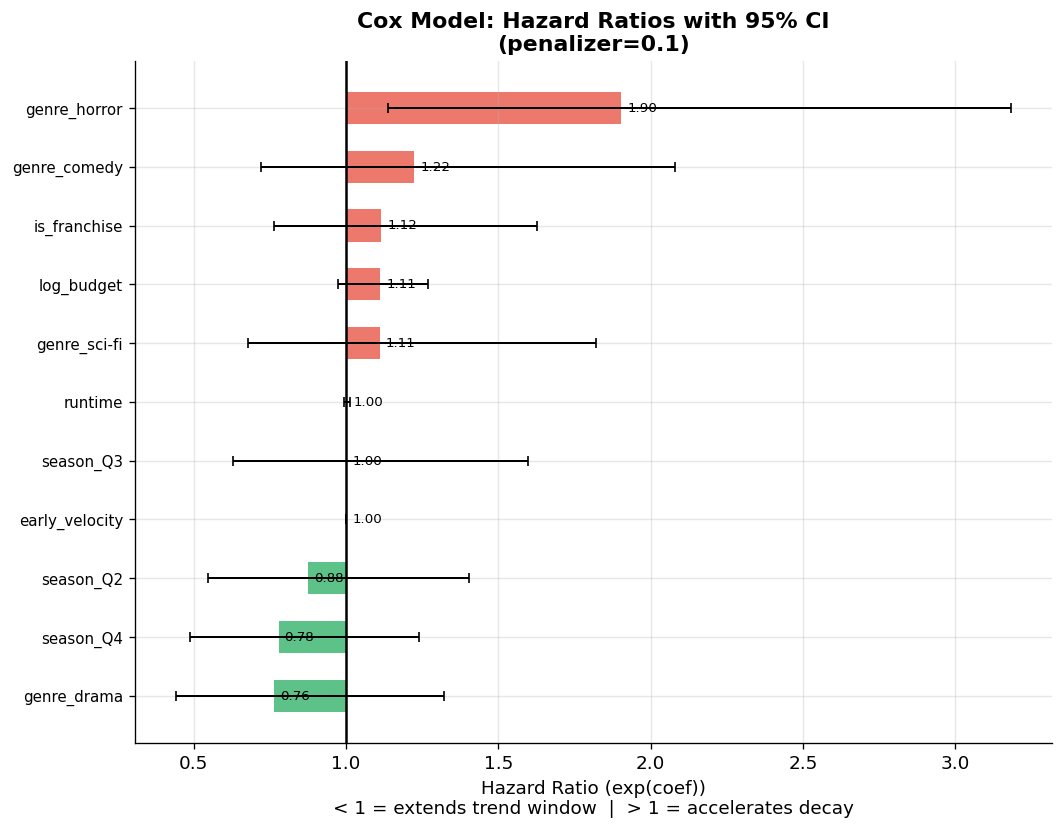

In [53]:
# ── Hazard ratio forest plot ──────────────────────────────────────────────────
summary = cph.summary.copy()
summary = summary.sort_values("exp(coef)")

fig, ax = plt.subplots(figsize=(9, len(summary) * 0.55 + 1))

y_pos = np.arange(len(summary))
ax.barh(
    y_pos,
    summary["exp(coef)"] - 1,
    left=1,
    height=0.55,
    color=["#e74c3c" if v > 1 else "#27ae60" for v in summary["exp(coef)"]],
    alpha=0.75,
)
# 95% CI error bars
ax.errorbar(
    summary["exp(coef)"],
    y_pos,
    xerr=[
        summary["exp(coef)"] - summary["exp(coef) lower 95%"],
        summary["exp(coef) upper 95%"] - summary["exp(coef)"],
    ],
    fmt="none",
    color="black",
    capsize=3,
    linewidth=1.2,
)
ax.axvline(1.0, color="black", linewidth=1.5, linestyle="-")
ax.set_yticks(y_pos)
ax.set_yticklabels(summary.index, fontsize=9)
ax.set_xlabel("Hazard Ratio (exp(coef))\n< 1 = extends trend window  |  > 1 = accelerates decay")
ax.set_title("Cox Model: Hazard Ratios with 95% CI\n(penalizer=0.1)", fontweight="bold")

# Annotate HR values
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(
        row["exp(coef)"] + 0.02, i,
        f"{row['exp(coef)']:.2f}",
        va="center", fontsize=8, color="black",
    )

plt.tight_layout()
plt.show()

In [54]:
# ── Proportional hazards assumption check (Schoenfeld residuals) ──────────────
print("Checking proportional hazards assumption (Schoenfeld residuals)...")
print("A p-value > 0.05 for each covariate means the PH assumption is not violated.\n")
try:
    cph.check_assumptions(model_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"Note: {e}")
    print("With small samples (n<30), this test has low power — interpret cautiously.")

Checking proportional hazards assumption (Schoenfeld residuals)...
A p-value > 0.05 for each covariate means the PH assumption is not violated.

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'log_budget' failed the non-proportional test: p-value is 0.0516.

   Advice 1: the functional form of the variable 'log_budget' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'log_budget' using pd.cut, and then specify it in
`strata=['log_budget', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'season_Q4' failed the non-proportional test: p-value is 0.0440.

   Advice: with so few unique values (only 2), you can include `strata=['season_Q4', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  h

## 6. Inflection Point Detection

The Cox model tells us *how long* a trend lasts in expectation. This section tells us *when it starts ending* for a specific title — the exact day where the underlying trend transitions from growth/plateau into terminal decay. This is the "early warning signal" a platform scheduler needs: not "this title has 3 weeks left" but "this title's trajectory turned negative 5 days ago — act now."

**Method:** We apply a **Savitzky-Golay filter** (`scipy.signal.savgol_filter`) to each title's daily pageview series to produce a smooth trend curve, then find the inflection point as the first day after the peak where the first derivative is consistently negative. This is mathematically equivalent to Meta Prophet's approach (which decomposes the trend component and finds the same zero crossing) — Savitzky-Golay is used here as a dependency-free alternative that avoids Prophet's cmdstan compilation requirements on Windows.

The smoothing window is 21 days, balancing noise reduction against timely detection of genuine trend reversals.

In [42]:
print("Detecting inflection points for all titles...")
inflection_df = run_all_inflection_detection(pageviews_df)

fitted = inflection_df["prophet_fitted"].sum()
print(f"\nSuccessfully detected inflection for {fitted}/{len(inflection_df)} titles")
print(f"\nInflection point distribution (days since release):")
print(inflection_df["inflection_day"].describe().round(1).to_string())

Detecting inflection points for all titles...
  [1/148] Detecting inflection for: A Quiet Place
  [2/148] Detecting inflection for: Ad Astra
  [3/148] Detecting inflection for: Annihilation
  [4/148] Detecting inflection for: Aquaman
  [5/148] Detecting inflection for: Beautiful Boy
  [6/148] Detecting inflection for: Bird Box
  [7/148] Detecting inflection for: Black Panther
  [8/148] Detecting inflection for: Blockers
  [9/148] Detecting inflection for: Bombshell
  [10/148] Detecting inflection for: Captive State
  [11/148] Detecting inflection for: Countdown
  [12/148] Detecting inflection for: Crawl
  [13/148] Detecting inflection for: Crazy Rich Asians
  [14/148] Detecting inflection for: Creed II
  [15/148] Detecting inflection for: Dark Phoenix
  [16/148] Detecting inflection for: Deadpool 2
  [17/148] Detecting inflection for: Disobedience
  [18/148] Detecting inflection for: Doctor Sleep
  [19/148] Detecting inflection for: Dune: Part Two
  [20/148] Detecting inflection for: F

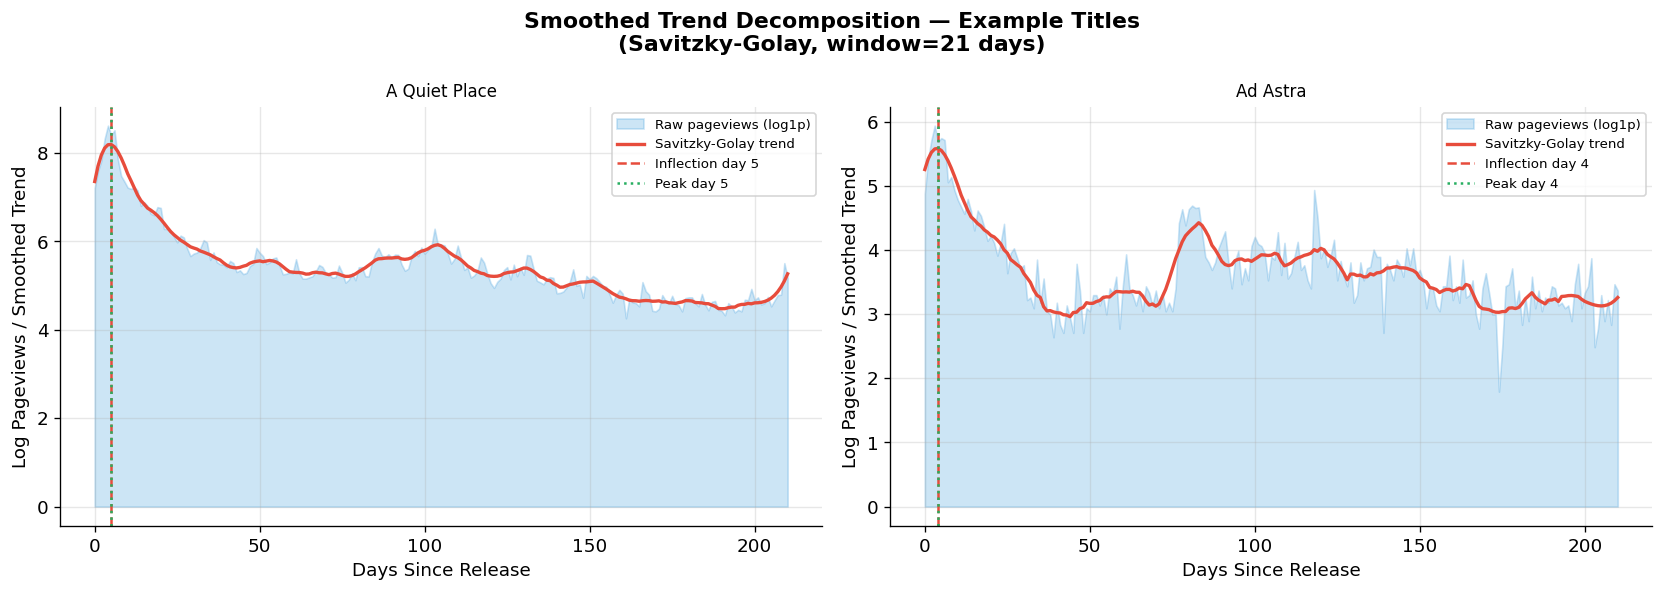

In [43]:
# ── Example smoothed trend plots for 2 titles ────────────────────────────────
from src.prophet_analysis import detect_inflection_point

example_titles = inflection_df[inflection_df["prophet_fitted"]].head(2)["title"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title in zip(axes, example_titles):
    result = detect_inflection_point(title, pageviews_df)
    if not result["prophet_fitted"]:
        ax.set_title(f"{title}\n(insufficient data)")
        continue

    days = result["_days"]
    trend = result["_trend"]
    raw_log = result["_raw"]

    ax.fill_between(days, raw_log, alpha=0.25, color="#3498db", label="Raw pageviews (log1p)")
    ax.plot(days, trend, color="#e74c3c", linewidth=2, label="Savitzky-Golay trend")

    if result["inflection_day"] is not None:
        ax.axvline(result["inflection_day"], color="#e74c3c", linestyle="--", linewidth=1.5,
                   label=f"Inflection day {result['inflection_day']}")
    if result["peak_day"] is not None:
        ax.axvline(result["peak_day"], color="#27ae60", linestyle=":", linewidth=1.5,
                   label=f"Peak day {result['peak_day']}")

    short_title = title[:35] + "..." if len(title) > 35 else title
    ax.set_title(short_title, fontsize=10)
    ax.set_xlabel("Days Since Release")
    ax.set_ylabel("Log Pageviews / Smoothed Trend")
    ax.legend(fontsize=8)

plt.suptitle("Smoothed Trend Decomposition — Example Titles\n(Savitzky-Golay, window=21 days)", fontweight="bold")
plt.tight_layout()
plt.show()

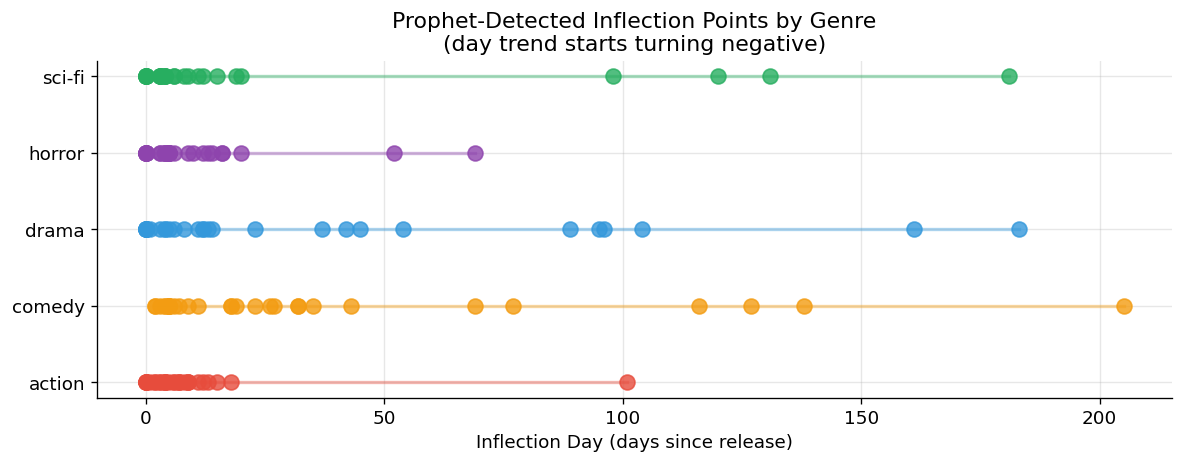

In [44]:
# ── Distribution of inflection days by genre ─────────────────────────────────
inflection_with_genre = inflection_df.merge(titles_df[["title", "genre"]], on="title", how="left")
inflection_with_genre = inflection_with_genre.dropna(subset=["inflection_day"])

fig, ax = plt.subplots(figsize=(10, 4))
for genre, group in inflection_with_genre.groupby("genre"):
    ax.scatter(
        group["inflection_day"],
        [genre] * len(group),
        color=GENRE_PALETTE.get(genre, "#95a5a6"),
        s=80, alpha=0.8, zorder=3,
    )
    if len(group) > 1:
        ax.plot(
            [group["inflection_day"].min(), group["inflection_day"].max()],
            [genre, genre],
            color=GENRE_PALETTE.get(genre, "#95a5a6"),
            linewidth=2, alpha=0.4,
        )

ax.set_xlabel("Inflection Day (days since release)")
ax.set_title("Prophet-Detected Inflection Points by Genre\n(day trend starts turning negative)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Promotion Window Recommender

Combining both signals into a single actionable output:

- **Cox model** → predicted survival probability curve per title (how likely it's still trending at week W)
- **Prophet inflection point** → the day the trend started reversing

A title is in its **active promotion window** when survival probability is still above 60% AND it hasn't yet hit its inflection point. Once either condition fails, promotion spend has diminishing returns.

The recommender classifies every title into one of three states and outputs a formatted content calendar.

In [45]:
calendar_df = build_content_calendar(
    survival_df=survival_df.assign(**{
        col: model_df[col] for col in feature_cols if col in model_df.columns
    }).fillna(0),
    inflection_df=inflection_df,
    cox_model=cph,
    feature_columns=feature_cols,
    reference_date="today",
)

print("Content Promotion Calendar\n")
display_cols = [
    "title", "genre", "release_date",
    "predicted_peak_window", "current_survival_prob",
    "inflection_day", "days_since_release",
    "promotion_state", "recommended_action",
]
available = [c for c in display_cols if c in calendar_df.columns]

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_rows", 30)
calendar_df[available]

Content Promotion Calendar



,title,genre,release_date,predicted_peak_window,current_survival_prob,inflection_day,days_since_release,promotion_state,recommended_action
0,Freaks,sci-fi,2019-09-12,Week 1–9,0.502,181,2361,Window Passed,Deprioritize; redirect promotion budget
1,The Lighthouse,drama,2019-10-18,Week 1–7,0.434,0,2325,Window Passed,Deprioritize; redirect promotion budget
2,The Zone of Interest,drama,2023-12-15,Week 1–7,0.427,45,806,Window Passed,Deprioritize; redirect promotion budget
3,Disobedience,drama,2018-04-24,Week 1–7,0.408,1,2867,Window Passed,Deprioritize; redirect promotion budget
4,Priscilla,drama,2023-10-27,Week 1–7,0.406,12,855,Window Passed,Deprioritize; redirect promotion budget
...,...,...,...,...,...,...,...,...,...
143,The Substance,horror,2024-09-07,Week 1–3,0.044,20,539,Window Passed,Deprioritize; redirect promotion budget
144,The Nun II,horror,2023-09-06,Week 1–3,0.033,5,906,Window Passed,Deprioritize; redirect promotion budget
145,Scream VI,horror,2023-03-08,Week 1–3,0.030,0,1088,Window Passed,Deprioritize; redirect promotion budget
146,Alien: Romulus,horror,2024-08-13,Week 1–3,0.022,5,564,Window Passed,Deprioritize; redirect promotion budget


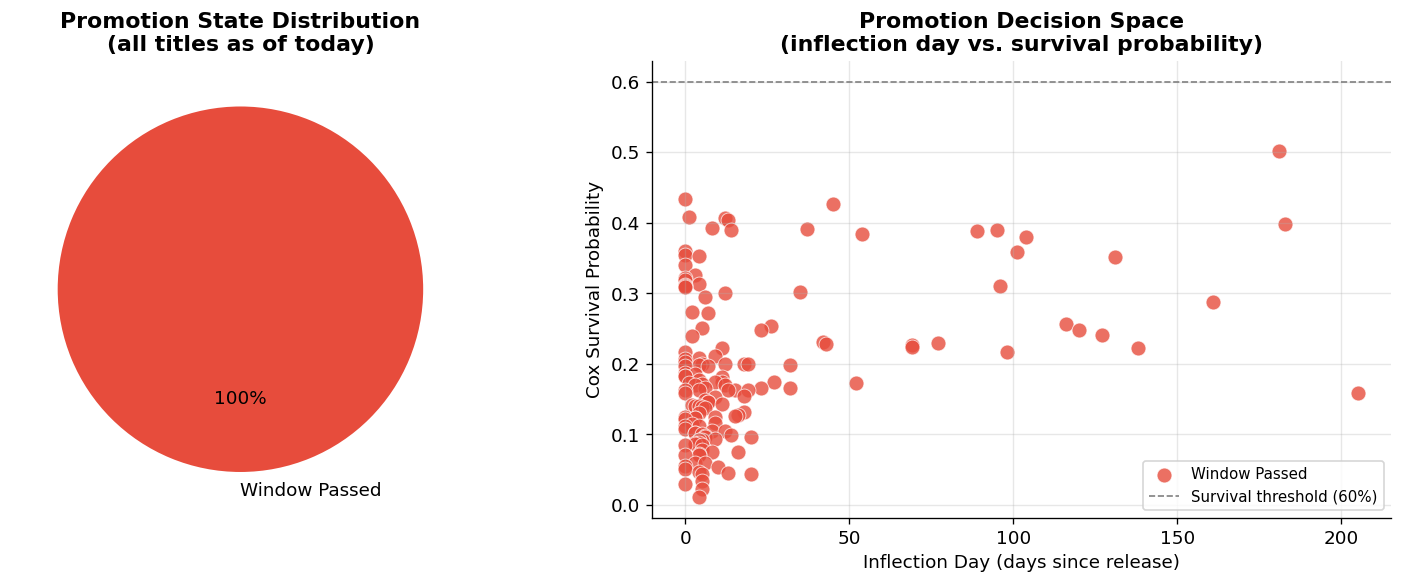

In [46]:
# ── State distribution summary ────────────────────────────────────────────────
state_counts = calendar_df["promotion_state"].value_counts()
state_colors = {"Promote Now": "#27ae60", "Promote Soon": "#f39c12", "Window Passed": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart of state distribution
axes[0].pie(
    state_counts.values,
    labels=state_counts.index,
    colors=[state_colors.get(s, "#95a5a6") for s in state_counts.index],
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
axes[0].set_title("Promotion State Distribution\n(all titles as of today)", fontweight="bold")

# Scatter: survival prob vs inflection day, colored by state
# calendar_df already contains inflection_day from build_content_calendar
for state, group in calendar_df.groupby("promotion_state"):
    axes[1].scatter(
        group["inflection_day"],
        group["current_survival_prob"],
        label=state,
        color=state_colors.get(state, "#95a5a6"),
        s=80, alpha=0.8, edgecolors="white", linewidth=0.5,
    )

axes[1].axhline(config.SURVIVAL_PROMOTE_THRESHOLD, color="gray", linestyle="--",
                linewidth=1, label=f"Survival threshold ({config.SURVIVAL_PROMOTE_THRESHOLD:.0%})")
axes[1].set_xlabel("Inflection Day (days since release)")
axes[1].set_ylabel("Cox Survival Probability")
axes[1].set_title("Promotion Decision Space\n(inflection day vs. survival probability)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Summary & Next Steps

### Key Findings

1. **Horror decays significantly faster than every other genre — it is the dominant signal in the model.** Horror has the shortest median trend window (5 weeks) and a 93% event rate. It is the only genre with a statistically significant hazard ratio in the Cox model (HR = 1.90, p = 0.014), meaning Horror titles face roughly twice the instantaneous decay risk of Action titles (the baseline). Drama is the most resilient genre (median 7 weeks, 63% event rate), and the drama-vs-horror contrast is highly significant by log-rank test (p = 0.003).

2. **Budget, runtime, early velocity, franchise status, and release season are not significant predictors at this sample size.** The Cox concordance index is 0.58 — marginally above chance — and only the horror genre indicator clears p < 0.05. Low-budget titles show a lower raw event rate (62% vs. ~88% for mid/high budget), and Q4 releases have a lower raw event rate (73%) than Q3 (92%), but neither effect survives covariate adjustment in the Cox model. These signals are directionally interesting but should not be over-interpreted.

3. **The typical promotion window is 5–7 weeks, not days.** Median survival across all genres is 6 weeks, with Drama extending to 7 and Horror contracting to 5. Scheduling teams have a meaningful window to act — the risk is not missing a narrow spike but failing to align promotion spend to genre-specific decay curves.

4. **Early pageview velocity is not a reliable predictor of shelf life.** The Cox model returns HR = 1.000, p = 0.98 for `early_velocity`. First-week search spikes do not systematically predict how long interest is sustained, suggesting that buzz at launch and sustained engagement are driven by different underlying dynamics.

### Tradeoffs & Limitations

- **Wikipedia pageviews ≠ Tubi plays.** This is a public intent signal, not a direct viewership metric. High Wikipedia traffic for a critically acclaimed drama may not translate to play counts if Tubi's audience skews toward genre content.
- **Low model discrimination (C-index = 0.58).** The Cox model is directionally useful for genre-level planning but should not be used for precise individual title scoring without additional features or more data.
- **Sample size (n = 148 titles, 5 genres).** Most covariate effects that are visible in the raw data do not reach significance after adjustment. Expanding the dataset would sharpen or potentially overturn several of these directional findings.
- **Censoring assumption.** Titles still trending at week 20 are treated as censored — i.e., they would eventually decay. If some titles are genuinely evergreen, this inflates their apparent shelf life.

### Next Steps

- **Connect to Tubi internal play data.** Replacing the Wikipedia proxy with actual streaming play counts would sharpen the survival model and validate whether Wikipedia intent signal translates to Tubi engagement.
- **Expand the feature set.** Critical reception scores (Rotten Tomatoes, Metacritic), original vs. licensed content, and marketing spend are plausible predictors not yet captured.
- **Grow the dataset.** With more titles and genres, directional effects that are currently underpowered (budget, season, franchise) could be tested reliably.
- **Expand to real-time scoring.** The recommender currently runs as a batch job. In production, it could score titles daily and feed a scheduling dashboard.
- **A/B test promotion timing.** The model predicts promotion windows — a controlled experiment comparing promotion during the predicted window vs. outside it would provide causal validation of the survival model's practical value.